# SHEIN E-Commerce Data Cleaning & Exploration

**Dataset:** [E-Commerce Data - SHEIN](https://www.kaggle.com/datasets/oleksiimartusiuk/e-commerce-data-shein) (Kaggle) — scraped product listing across SHEIN product categories (appliances, automotive, beauty, electronics, etc.)

**Objective:** Consolidate the per-category CSV exports into a single clean, analysis-ready dataset, then run a first exploratory pass comparing pricing, discounting, sales-values patterns across categories, and provide a basic statistical evaluation on discount effectiveness.

**Approach:**
1. Load and inventory each category file
2. Diagnose messy/inconsistent formatting per column
3. Clean and standardize types
4. Merge into one dataframe and validate the result
5. Explore patterns across categories
6. Export a clean CSV for downstream use

**Note on data quality:** several fields (like "quantity sold") are inferred from marketing strings scraped off the listing page (e.g. `"500+ sold"`), not a verified transactional field. Results here should be read as directional/comparative, not exact. 

## 1. Load Data

Download the dataset via `kagglehub` and read each category file into its own dataframe. I keep them separate at first (rather than concatenating immediately) so I can inspect category-specific quirks before merging.

In [ ]:
# Set up

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os   
import kagglehub
from scipy.stats import pearsonr, spearmanr

In [ ]:
# Download dataset latest version
path = kagglehub.dataset_download("oleksiimartusiuk/e-commerce-data-shein")

print("Path to dataset files:", path)

In [3]:
os.listdir(path)

['us-shein-appliances-3987.csv',
 'us-shein-automotive-4110.csv',
 'us-shein-baby_and_maternity-4433.csv',
 'us-shein-bags_and_luggage-4299.csv',
 'us-shein-beauty_and_health-4267.csv',
 'us-shein-curve-2849.csv',
 'us-shein-electronics-4395.csv',
 'us-shein-home_and_kitchen-3719.csv',
 'us-shein-home_textile-3883.csv',
 'us-shein-jewelry_and_accessories-3548.csv',
 'us-shein-kids-4314.csv',
 'us-shein-mens_clothes-1891.csv',
 'us-shein-office_and_school_supplies-4233.csv',
 'us-shein-pet_supplies-4083.csv',
 'us-shein-shoes-4381.csv',
 'us-shein-sports_and_outdoors-3853.csv',
 'us-shein-swimwear-3761.csv',
 'us-shein-tools_and_home_improvement-3903.csv',
 'us-shein-toys_and_games-3577.csv',
 'us-shein-underwear_and_sleepwear-4019.csv',
 'us-shein-womens_clothing-4620.csv']

Each file name encodes its category (e.g. `us-shein-appliances-3987.csv`), so I parse the category out of the filename while reading each file in, and store the results in a dict keyed by category. 

In [4]:
df_dict = {}
file_names = os.listdir(path)
index = []

for file in file_names:
    category = file.split('-')[2]
    index.append(category)
    df_dict[category] = pd.read_csv(path + '/' + file)

    print(f'{category}:\n{df_dict[category].shape[0]} rows, {df_dict[category].shape[1]} columns')
    print(f'{df_dict[category].columns}\n')

appliances:
3986 rows, 8 columns
Index(['goods-title-link--jump', 'goods-title-link--jump href', 'rank-title',
       'rank-sub', 'price', 'discount', 'selling_proposition',
       'goods-title-link'],
      dtype='str')

automotive:
4109 rows, 6 columns
Index(['goods-title-link--jump', 'goods-title-link--jump href', 'price',
       'discount', 'selling_proposition', 'goods-title-link'],
      dtype='str')

baby_and_maternity:
4432 rows, 7 columns
Index(['goods-title-link--jump', 'goods-title-link--jump href',
       'selling_proposition', 'price', 'discount', 'color-count',
       'goods-title-link'],
      dtype='str')

bags_and_luggage:
4298 rows, 9 columns
Index(['color-count', 'goods-title-link--jump', 'goods-title-link--jump href',
       'selling_proposition', 'price', 'discount', 'rank-title', 'rank-sub',
       'goods-title-link'],
      dtype='str')

beauty_and_health:
4266 rows, 9 columns
Index(['goods-title-link--jump', 'goods-title-link--jump href',
       'selling_proposi

In [5]:
# Does the number of files match the number of categories?

if len(index) == len(file_names):
    print('Each file is a unique category')
else:
    print('One file has been overwritten')

Each file is a unique category


## 2. Initial Structure Exploration 

Before cleaning anything, I check what can be found in these files: which columns exist across all categories, which are unique to just a few, and what the raw values look like.

In [6]:
total_cols = set().union(*(df_dict[i].columns for i in index))
print(f'{len(total_cols)} unique columns total\n', total_cols)

common_cols = set.intersection(*(set(df_dict[i].columns) for i in index))
print(f'\n{len(common_cols)} unique columns shared\n', common_cols)

12 unique columns total
 {'rank-sub', 'goods-title-link', 'selling_proposition', 'blackfridaybelts-content', 'goods-title-link--jump', 'goods-title-link--jump href', 'price', 'rank-title', 'color-count', 'discount', 'blackfridaybelts-bg src', 'product-locatelabels-img src'}

3 unique columns shared
 {'price', 'discount', 'goods-title-link'}


In [7]:
for i in index:
    print(f'\n{i}:\n')
    print(f'{df_dict[i].info()}\n')


appliances:

<class 'pandas.DataFrame'>
RangeIndex: 3986 entries, 0 to 3985
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   goods-title-link--jump       40 non-null     str  
 1   goods-title-link--jump href  40 non-null     str  
 2   rank-title                   559 non-null    str  
 3   rank-sub                     559 non-null    str  
 4   price                        3986 non-null   str  
 5   discount                     2459 non-null   str  
 6   selling_proposition          1361 non-null   str  
 7   goods-title-link             3946 non-null   str  
dtypes: str(8)
memory usage: 249.3 KB
None


automotive:

<class 'pandas.DataFrame'>
RangeIndex: 4109 entries, 0 to 4108
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   goods-title-link--jump       40 non-null     str  
 1   goods

In [8]:
df_dict['sports_and_outdoors'].sample(7)

,color-count,blackfridaybelts-bg src,blackfridaybelts-content,goods-title-link--jump,goods-title-link--jump href,rank-title,rank-sub,price,discount,selling_proposition,goods-title-link
1261,NaN,NaN,NaN,NaN,NaN,#2 Best Sellers,in Hula Hoop,$10.14,-7%,NaN,JLoibao Weighted Hula Circle Hoops For Adults ...
2128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$2.80,-13%,1.0k+ sold recently,Plush Cartoon Bear Shaped Keychain Cute Key Ri...
1481,23.0,https://img.ltwebstatic.com/images3_ccc/2023/1...,Save $4.97,NaN,NaN,NaN,NaN,$14.92,-25%,200+ sold recently,SHEIN Sport Studio Women's Solid Color Round N...
3223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$3.70,NaN,1.4k+ sold recently,1pair Black Nylon Pull-Up Assist Band With Wri...
556,7.0,NaN,NaN,NaN,NaN,NaN,NaN,$5.94,-60%,400+ sold recently,SHEIN LUNE Solid Drop Shoulder Hoodie
765,NaN,https://img.ltwebstatic.com/images3_ccc/2023/1...,Save $3.75,NaN,NaN,NaN,NaN,$11.25,-25%,100+ sold recently,2024 New Arrival Women Beige Fashionable Athle...
738,NaN,NaN,NaN,NaN,NaN,#10 Best Sellers,in Running & Work Out Women Sports Tees & Tanks,$5.69,NaN,NaN,SHEIN Sport Gameset Letter Graphic Sports Tank...


In [9]:
cols_unique_check = [
    'color-count',
    'blackfridaybelts-content',
    'rank-title',
    'discount',
    'selling_proposition'
]

for col in cols_unique_check:
    print(f'\n{col}:\n')
    print(f'{df_dict["sports_and_outdoors"][col].unique()}\n')


color-count:

[ 5. nan  8. 13.  7.  4. 18. 12.  6. 14. 23. 10. 15.  9. 22. 20. 17. 19.
 16. 11. 29. 26. 37. 32. 21.]


blackfridaybelts-content:

<StringArray>
[ 'Save $5.24',           nan,  'Save $6.53',  'Save $2.55',  'Save $7.59',
  'Save $0.46',  'Save $4.75',  'Save $9.11',  'Save $6.08',  'Save $0.71',
 ...
  'Save $9.68',  'Save $0.26',  'Save $6.84',  'Save $7.27',  'Save $6.93',
  'Save $6.67',  'Save $3.70', 'Save $14.87',  'Save $7.69',  'Save $7.16']
Length: 531, dtype: str


rank-title:

<StringArray>
[ '#9 Best Sellers',  '#5 Best Sellers',   '#1 Best Seller',
                nan,  '#4 Best Sellers',  '#1 Best Sellers',
   '#5 Best Seller',  '#6 Best Sellers',  '#3 Best Sellers',
 '#10 Best Sellers',  '#7 Best Sellers',   '#3 Best Seller',
  '#8 Best Sellers',   '#4 Best Seller',  '#2 Best Sellers',
   '#7 Best Seller',   '#9 Best Seller',  '#10 Best Seller',
   '#8 Best Seller',   '#2 Best Seller',   '#6 Best Seller']
Length: 21, dtype: str


discount:

<StringArray>


### Missing values overview

A quick look at null rates per column, per category, before deciding how to handle them.

In [10]:
# Do the missing values in 'goods-title-link' match with the amount of non-na values in 'goods-title-link--jump'?

df_dict['sports_and_outdoors'][df_dict['sports_and_outdoors']['goods-title-link'].isna()]['goods-title-link--jump'].notna().sum()

np.int64(39)

Given this result, it is possible to merge these two columns and delete one of them.

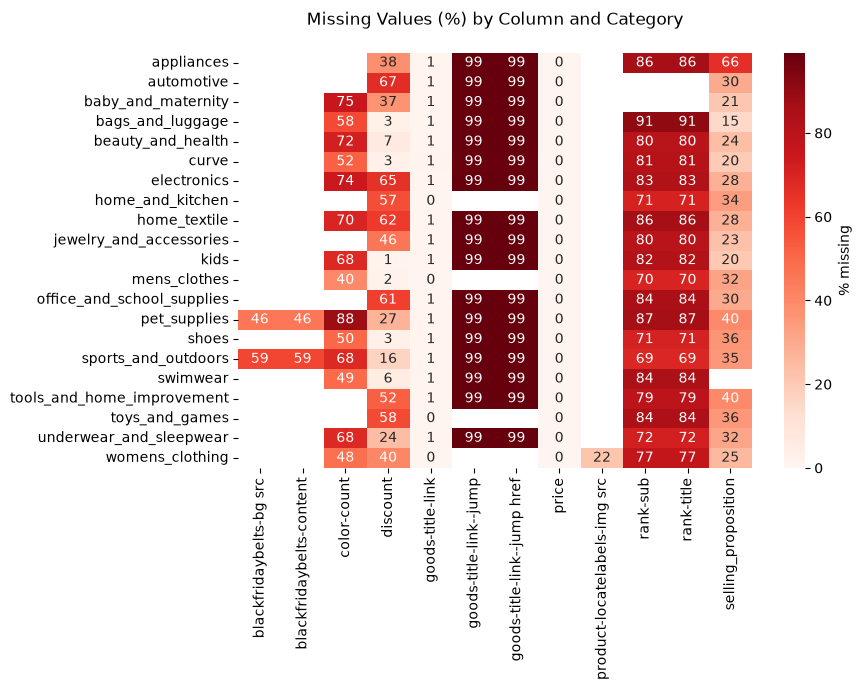

,blackfridaybelts-bg src,blackfridaybelts-content,color-count,discount,goods-title-link,goods-title-link--jump,goods-title-link--jump href,price,product-locatelabels-img src,rank-sub,rank-title,selling_proposition
appliances,NaN,NaN,NaN,38.3,1.0,99.0,99.0,0.0,NaN,86.0,86.0,65.9
automotive,NaN,NaN,NaN,66.6,1.0,99.0,99.0,0.0,NaN,NaN,NaN,30.1
baby_and_maternity,NaN,NaN,75.4,36.8,0.9,99.1,99.1,0.0,NaN,NaN,NaN,21.0
bags_and_luggage,NaN,NaN,58.3,3.4,0.9,99.1,99.1,0.0,NaN,90.6,90.6,15.0
beauty_and_health,NaN,NaN,71.7,6.6,0.9,99.1,99.1,0.0,NaN,80.4,80.4,23.7
curve,NaN,NaN,51.9,2.8,1.4,98.6,98.6,0.0,NaN,81.3,81.3,19.5
electronics,NaN,NaN,74.1,65.3,0.9,99.1,99.1,0.0,NaN,83.0,83.0,27.9
home_and_kitchen,NaN,NaN,NaN,57.1,0.0,NaN,NaN,0.0,NaN,70.7,70.7,33.8
home_textile,NaN,NaN,69.7,62.2,1.0,99.0,99.0,0.0,NaN,86.5,86.5,27.9
jewelry_and_accessories,NaN,NaN,NaN,45.7,1.1,98.9,98.9,0.0,NaN,79.8,79.8,22.9


In [11]:
missing_pct = pd.DataFrame({cat: df_dict[cat].isna().mean() for cat in df_dict}).T * 100
missing_pct = missing_pct.round(1)

plt.figure(figsize=(9, 7))
sns.heatmap(missing_pct, annot=True, fmt='.0f', cmap='Reds',
            mask=missing_pct.isna(), cbar_kws={'label': '% missing'})
plt.title('Missing Values (%) by Column and Category\n')
plt.tight_layout()
plt.show()

missing_pct

## 3. Data Cleaning

Based on the exploration above, here's what needs fixing:

- add a `category` column (lost once files are separated)
- add an `id` column in the merging step, so it is possible to keep track of each item throughout each step
- consolidate `goods-title-link`/`goods-title-link--jump` into a single item-name column
- drop the raw fields for consistent grouping 
- parse `blackfridaybelts-content`, `rank-title`, `discount`, `selling_proposition`, and `price` out of their string formats into numeric types

**Note on `selling_proposition`:** this field holds strings like `"500+ sold"`. I treat it as an approximate units-sold figure (renamed to `qty_sold` later), but it's a marketing label, not a verified sales count — so downstream revenue figures are estimates, not ground truth.

In [12]:
def clean_df(df, key=None):

# Category column:

    """
    Clean a single category dataframe in place.

    Parameters 
    ----------
    df : pd.DataFrame
        Raw category dataframe (one per product category).
    key : str
        Category name, stored in the new 'category' column.

    Notes
    -----
    Column-specific transforms only run if that column exists,
    since column availability differs across categories.
    """

    df['category'] = key

# Item name:
    if ('goods-title-link--jump' in df.columns) and ('goods-title-link' in df.columns):
        df['goods-title-link'] = df['goods-title-link'].str.lower()
        df.loc[:,'goods-title-link'] = df['goods-title-link'].fillna(df['goods-title-link--jump'].str.lower())
        df.drop(columns=['goods-title-link--jump','goods-title-link--jump href'], inplace=True)

# Black Friday:
    if 'blackfridaybelts-content' in df.columns:
        df['blackfridaybelts-content'] = (
                                            pd.to_numeric(
                                                df['blackfridaybelts-content']
                                                .astype(str) 
                                                .str.strip()
                                                .str.replace('Save $',''), 
                                                errors='coerce'
                                            )
                                          )
        df.drop(columns=['blackfridaybelts-bg src'], inplace=True)
        df['NAN_b_friday_off'] = (df['blackfridaybelts-content'].isna()).astype(int)

# Rank Title
    if 'rank-title' in df.columns:
        df['rank-title'] = (
                                pd.to_numeric(
                                    df['rank-title']
                                    .astype(str) 
                                    .str.strip()
                                    .str.replace(r'\D','', regex=True), 
                                    errors='coerce'
                                )
                            )
        df['rank-sub'] = df['rank-sub'].str.lower()
        df['NAN_sub_cat_rank'] = (df['rank-title'].isna()).astype(int)

# Discount
    if 'discount' in df.columns:
        df['discount'] = (
                            pd.to_numeric( 
                                df['discount']
                                .astype(str) 
                                .str.strip()
                                .str.replace('%',''), 
                                errors='coerce'
                            ).abs()
                          )
        df['NAN_discount_pct'] = (df['discount'].isna()).astype(int)

# Selling Proposition
    if 'selling_proposition' in df.columns:
        df['selling_proposition'] = (
                                        pd.to_numeric(
                                            df['selling_proposition']
                                            .astype(str)
                                            .str.extract(r'(\d+\.?\d*k?)', expand=False)
                                            .str.replace('k','e3'),
                                            errors='coerce'
                                        )
                                     )
        df['NAN_qty_sold'] = (df['selling_proposition'].isna()).astype(int)

# Price
    if 'price' in df.columns:
        df['price'] = (
                        pd.to_numeric(
                            df['price']
                            .astype(str)
                            .str.replace('$',''),
                            errors='coerce'
                        )
                       )

In [13]:
for key in df_dict:
    clean_df(df_dict[key], key)
    print(f'CLEANING COMPLETED: {key}')

CLEANING COMPLETED: appliances
CLEANING COMPLETED: automotive
CLEANING COMPLETED: baby_and_maternity
CLEANING COMPLETED: bags_and_luggage
CLEANING COMPLETED: beauty_and_health
CLEANING COMPLETED: curve
CLEANING COMPLETED: electronics
CLEANING COMPLETED: home_and_kitchen
CLEANING COMPLETED: home_textile
CLEANING COMPLETED: jewelry_and_accessories
CLEANING COMPLETED: kids
CLEANING COMPLETED: mens_clothes
CLEANING COMPLETED: office_and_school_supplies
CLEANING COMPLETED: pet_supplies
CLEANING COMPLETED: shoes
CLEANING COMPLETED: sports_and_outdoors
CLEANING COMPLETED: swimwear
CLEANING COMPLETED: tools_and_home_improvement
CLEANING COMPLETED: toys_and_games
CLEANING COMPLETED: underwear_and_sleepwear
CLEANING COMPLETED: womens_clothing


## 4. Merge Categories

With every category dataframe cleaned individually, I concatenate them into one dataframe. Column sets differ by category, so some columns will be sparse (NaN) for categories that never had that field to begin with — that's expected, not a bug.

In [14]:
df = pd.concat([df_dict[key] for key in df_dict], ignore_index=True, sort=False)
df

,rank-title,rank-sub,price,discount,selling_proposition,goods-title-link,category,NAN_sub_cat_rank,NAN_discount_pct,NAN_qty_sold,color-count,blackfridaybelts-content,NAN_b_friday_off,product-locatelabels-img src
0,1.0,in give gifts,2.03,22.0,NaN,1pc rechargeable deep tissue muscle handheld m...,appliances,0.0,0,1.0,NaN,NaN,NaN,NaN
1,4.0,in top rated in portable fans,6.48,20.0,NaN,1pc portable hanging neck fan,appliances,0.0,0,1.0,NaN,NaN,NaN,NaN
2,NaN,NaN,1.80,NaN,400.0,1pc pink colored curved eyelash curler false e...,appliances,1.0,1,0.0,NaN,NaN,NaN,NaN
3,NaN,NaN,0.88,72.0,5600.0,1 mini portable handheld fan with 2 aa batteri...,appliances,1.0,0,0.0,NaN,NaN,NaN,NaN
4,6.0,in oral irrigators,12.06,40.0,NaN,"wit water flosser,portable oral irrigator with...",appliances,0.0,0,1.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82100,2.0,in modest world apparel,35.69,NaN,NaN,Colorful Flower Embroidered Linen Muslim Women...,womens_clothing,0.0,1,1.0,NaN,NaN,NaN,NaN
82101,NaN,NaN,42.49,NaN,10.0,Elegant And Stylish Patchwork Lace Cheongsam D...,womens_clothing,1.0,1,0.0,NaN,NaN,NaN,NaN
82102,NaN,NaN,49.29,NaN,200.0,Split Thigh Satin Tube Prom Dress,womens_clothing,1.0,1,0.0,5.0,NaN,NaN,NaN
82103,10.0,in sexy women bottoms,9.78,5.0,NaN,DAZY Women's Solid Color Low Waist Ultra Short...,womens_clothing,0.0,0,1.0,6.0,NaN,NaN,NaN


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 82105 entries, 0 to 82104
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   rank-title                    14605 non-null  float64
 1   rank-sub                      14605 non-null  str    
 2   price                         82080 non-null  float64
 3   discount                      54977 non-null  float64
 4   selling_proposition           54364 non-null  float64
 5   goods-title-link              82091 non-null  str    
 6   category                      82105 non-null  str    
 7   NAN_sub_cat_rank              73564 non-null  float64
 8   NAN_discount_pct              82105 non-null  int64  
 9   NAN_qty_sold                  78345 non-null  float64
 10  color-count                   19743 non-null  float64
 11  blackfridaybelts-content      3791 non-null   float64
 12  NAN_b_friday_off              7934 non-null   float64
 13  product-loca

In [16]:
df.rename(
    columns={
        'rank-title':'sub_cat_rank',
        'rank-sub':'sub_cat',
        'price':'price_usd',
        'discount': 'discount_pct',
        'selling_proposition': 'qty_sold',
        'goods-title-link':'item_name',
        'color-count':'color_count',
        'product-locatelabels-img src':'img_url',
        'blackfridaybelts-content': 'b_friday_off'
    },
    inplace=True
)

In [17]:
df = df.reset_index(names='id')

In [18]:
round(df.isna().mean()*100,2)

id                   0.00
sub_cat_rank        82.21
sub_cat             82.21
price_usd            0.03
discount_pct        33.04
qty_sold            33.79
item_name            0.02
category             0.00
NAN_sub_cat_rank    10.40
NAN_discount_pct     0.00
NAN_qty_sold         4.58
color_count         75.95
b_friday_off        95.38
NAN_b_friday_off    90.34
img_url             95.59
dtype: float64

`swimwear` has no `qty_sold` data at all, so it's excluded from later analysis involving that column. Separately, a small set of plots will compare results with missing `qty_sold` values kept as-is versus replaced with zero, under the assumption of no sales yet. 

## 5. Deduplication & Missing Value Handling

A couple of decisions here:

- **Duplicates:** identical rows will be considered scrape artifacts (same listing pulled twice), so I drop them outright. 
- **Missing Values:** 
    - `sub_cat`: replace with 'unknown' label; I assume it corresponds to an item out of the rank and therefore not showing a subcat label.
    - `sub_cat_rank`: keep; I assume this item is not included in any rank. 
    - `qty_sold`: keep; in further analysis it could be useful to compare analysis using items with its volume sales known and analysis replacing missing values with zero (under the assumption that it has no sales yet)
    - `color_count`: replace with 1; I assume it is one color option available.
    - `b_friday_off`: replace with 0; I assume it implies no discount. Yet they seem to have been scraped for `pet_supplies` and `sports_and_outdoors` categories only.
    - `price_usd`: drop rows with missing values; a listing with no price can't be used in any comparison.
    - `discount_pct`: replace with 0; I assume it implies no discount.
    - `item_name`: drop rows with missing values; a listing without identifying the item can't be used in any comparison.
    - `img_url`: only womens_clothing contains non-na values, therefore this column will be entirely dropped for saving memory.
    - `NAN flag columns`: replace with -1; since many source columns aren't shared across the category files this will be used as a third state (distinct from 0/1), for "this field didn't exist for this category" rather than a string label.
    - `qty_sold` in `swimwear`: category excluded; in the following price and volume sales it should not be included.

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df = df.drop_duplicates()
df.shape

(82105, 15)

In [21]:
def nan_manager(df):
    df_m = df.copy()

    fill_values = {
        'sub_cat': 'unknown',
        'color_count': 1,
        'b_friday_off': 0,
        'discount_pct': 0
    }
    
    existing_fill_cols = {k: v for k, v in fill_values.items() if k in df_m.columns}
    df_m = df_m.fillna(value=existing_fill_cols)

    critical_cols = [c for c in ['price_usd', 'item_name'] if c in df_m.columns]
    if critical_cols:
        df_m = df_m.dropna(subset=critical_cols)

    if 'img_url' in df_m.columns:
        df_m = df_m.drop(columns=['img_url'])

    nan_col = [col for col in df_m.select_dtypes(include=['float64']).columns if col.startswith("NAN_")]
    df_m[nan_col] = df_m[nan_col].fillna(-1).astype(int)

    return df_m

In [22]:
print(df.shape)

df_cl = nan_manager(df)
print(df_cl.shape)

(82105, 15)
(82068, 14)


In [23]:
df_cl = df_cl.reset_index(drop=True)

### Post-cleaning validation

Before moving on, I check that the cleaning actually did what it was supposed to — no leftover formatting artifacts, and no impossible values.

In [24]:
print("=== Post-cleaning validation ===\n")

# No leftover currency/percentage symbols
symbol_check = {
    'price_usd': r'\$',
    'discount_pct': '%',
}
for col, pattern in symbol_check.items():
    bad = df_cl[col].astype(str).str.contains(pattern, regex=True).sum()
    flag = " \u26a0\ufe0f" if bad else " \u2713"
    print(f"{col}: {bad} values still contain '{pattern}'" + flag)

# Expected numeric dtypes
expected_numeric = ['sub_cat_rank', 'price_usd', 'discount_pct', 'qty_sold', 'color_count', 'b_friday_off']
for col in expected_numeric:
    ok = pd.api.types.is_numeric_dtype(df_cl[col])
    status = "numeric \u2713" if ok else "NOT numeric \u26a0\ufe0f"
    print(f"{col}: {status}")

# Sanity ranges
print(f"\nNegative prices: {(df_cl['price_usd'] < 0).sum()}")
print(f"Negative qty_sold: {(df_cl['qty_sold'] < 0).sum()}")
print(f"Negative discount_pct (unexpected sign): {(df_cl['discount_pct'] < 0).sum()}")

# Remaining nulls
print("\nRemaining nulls per column:")
nulls = df_cl.isna().sum()
print(nulls[nulls > 0] if (nulls > 0).any() else "None")

=== Post-cleaning validation ===

price_usd: 0 values still contain '\$' ✓
discount_pct: 0 values still contain '%' ✓
sub_cat_rank: numeric ✓
price_usd: numeric ✓
discount_pct: numeric ✓
qty_sold: numeric ✓
color_count: numeric ✓
b_friday_off: numeric ✓

Negative prices: 0
Negative qty_sold: 0
Negative discount_pct (unexpected sign): 0

Remaining nulls per column:
sub_cat_rank    67468
qty_sold        27710
dtype: int64


## 6. Feature Engineering 

With clean numeric fields, I can derive a rough `revenue` estimate per listing (price x estimated quantity sold). Given the caveat above about `qty_sold` being an inferred marketing figure, `revenue` must be treated as directional — useful for comparing categories relative to each other, not as an exact dollar figure. 

Furthermore, a temporal purged dataframe will be used for a quick analysis. As a different scenario, nan values could be interpreted as no sales yet (and therefore be replaced for zero values); nonetheless, here I will be conservative and focus in what is known.

In [25]:
df_an = df_cl.copy()
df_an = df_an[df_an.category != 'swimwear']
df_an = df_an.dropna(subset=['qty_sold']).reset_index(drop=True)

index_an = [x for x in index if x != 'swimwear']

In [26]:
df_an['revenue'] = df_an['price_usd'] * df_an['qty_sold']

In [27]:
df_an.info()

<class 'pandas.DataFrame'>
RangeIndex: 54358 entries, 0 to 54357
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                54358 non-null  int64  
 1   sub_cat_rank      0 non-null      float64
 2   sub_cat           54358 non-null  str    
 3   price_usd         54358 non-null  float64
 4   discount_pct      54358 non-null  float64
 5   qty_sold          54358 non-null  float64
 6   item_name         54358 non-null  str    
 7   category          54358 non-null  str    
 8   NAN_sub_cat_rank  54358 non-null  int64  
 9   NAN_discount_pct  54358 non-null  int64  
 10  NAN_qty_sold      54358 non-null  int64  
 11  color_count       54358 non-null  float64
 12  b_friday_off      54358 non-null  float64
 13  NAN_b_friday_off  54358 non-null  int64  
 14  revenue           54358 non-null  float64
dtypes: float64(7), int64(5), str(3)
memory usage: 6.2 MB


## 7. Exploratory Analysis

With one clean dataframe, I look at how categories compare on number of listings, discounting, sales volume, and revenue.

**Number of listings weight check.** I begin with a quick test using a Spearman's correlation (given that the data is highly skewed), to spot any possible bias explained by the sample size differences.

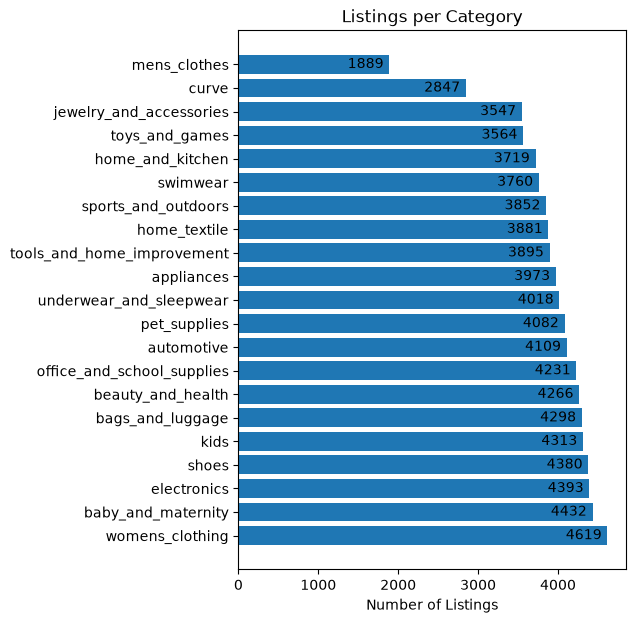

In [28]:
amount_cat = df_cl.category.value_counts()

fig, ax = plt.subplots(figsize=(5, 7))

bars = ax.barh(list(amount_cat.index), list(amount_cat.values))
ax.bar_label(bars, padding=-30)
ax.set_xlabel("Number of Listings")
ax.set_title("Listings per Category")

plt.show()

In [29]:
listing_counts = df_an.category.value_counts()

print("Remaining pct for analysis\n", f'total: {round(df_an.shape[0] / df_cl.shape[0] *100, 2)}', f' ({df_an.shape[0] - df_cl.shape[0]} rows)')
round(listing_counts / amount_cat *100, 2)

Remaining pct for analysis
 total: 66.24  (-27710 rows)


category
appliances                    34.26
automotive                    69.94
baby_and_maternity            78.99
bags_and_luggage              84.97
beauty_and_health             76.35
curve                         80.54
electronics                   72.09
home_and_kitchen              66.17
home_textile                  72.07
jewelry_and_accessories       77.14
kids                          79.64
mens_clothes                  67.60
office_and_school_supplies    69.91
pet_supplies                  60.34
shoes                         63.90
sports_and_outdoors           64.72
swimwear                        NaN
tools_and_home_improvement    60.05
toys_and_games                64.45
underwear_and_sleepwear       68.34
womens_clothing               74.73
Name: count, dtype: float64

In [30]:
revenue_per_cat = df_an.groupby('category')['revenue'].mean()
qty_sold_per_cat = df_an.groupby('category')['qty_sold'].mean()

corr_check = pd.DataFrame({
    'n_listings': listing_counts,
    'mean_revenue': revenue_per_cat,
    'mean_qty_sold': qty_sold_per_cat
})
corr_check.corr(method='spearman')

,n_listings,mean_revenue,mean_qty_sold
n_listings,1.000000,0.093233,0.183459
mean_revenue,0.093233,1.000000,0.828571
mean_qty_sold,0.183459,0.828571,1.000000


The correlation between the number of listings and mean quantity sold is not significant. The difference in sample sizes will not interfere in further analysis.

In [31]:
df_an.describe()

,id,sub_cat_rank,price_usd,discount_pct,qty_sold,NAN_sub_cat_rank,NAN_discount_pct,NAN_qty_sold,color_count,b_friday_off,NAN_b_friday_off,revenue
count,54358.000000,0.0,54358.000000,54358.000000,54358.000000,54358.000000,54358.000000,54358.0,54358.000000,54358.000000,54358.000000,54358.000000
mean,39773.592719,NaN,7.885241,14.901689,976.578608,0.765444,0.332076,0.0,2.699713,0.109822,-0.865981,6680.239207
std,23245.444077,NaN,14.799932,17.142159,1695.934152,0.643509,0.470963,0.0,3.887445,0.701478,0.449169,14981.752907
min,2.000000,NaN,0.150000,0.000000,10.000000,-1.000000,0.000000,0.0,1.000000,0.000000,-1.000000,2.700000
25%,19843.250000,NaN,2.300000,0.000000,100.000000,1.000000,0.000000,0.0,1.000000,0.000000,-1.000000,420.000000
50%,38320.000000,NaN,5.070000,8.000000,300.000000,1.000000,0.000000,0.0,1.000000,0.000000,-1.000000,1512.000000
75%,57900.500000,NaN,9.990000,23.000000,1000.000000,1.000000,1.000000,0.0,1.000000,0.000000,-1.000000,5890.000000
max,82102.000000,NaN,899.990000,92.000000,10000.000000,1.000000,1.000000,0.0,39.000000,22.820000,1.000000,308900.000000


In [32]:
def dup_plot_per_cat(kind, x1, y1, x2, y2, sharey=False, title_1=None, 
                     title_2=None, y1_label=None, y2_label=None, **kwargs):

    plot = {'bar':sns.barplot, 'box':sns.boxplot}

    fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14,5), sharex=True, sharey=sharey)

    plot[kind](x=x1, y=y1, hue=x1, legend=True, ax=ax1, **kwargs)
    ax1.grid(axis='y', alpha=0.5)
    ax1.set_axisbelow(True)
    ax1.set_xlabel(None)
    ax1.set_xticks(range(len(index_an)), range(1,len(index_an)+1))
    ax1.set_ylabel(y1_label)
    ax1.set_title(title_1)

    plot[kind](x=x2, y=y2, hue=x2, ax=ax2, **kwargs)
    ax2.grid(axis='y', alpha=0.5)
    ax2.set_axisbelow(True)
    ax2.set_xlabel(None)
    ax2.set_ylabel(y2_label)
    ax2.set_title(title_2)

    handles,_ = ax1.get_legend_handles_labels()
    plt.legend(handles, labels, title='Category\n', bbox_to_anchor=(1.1,1.05), fontsize='small')
    if ax1.get_legend(): ax1.get_legend().remove()

    plt.show()

**Average quantity sold and revenue by category**. Given the scraping method, all items which contain less than 10 sales does not contain data on quantity sold. Therefore read this as a rough comparison, not a precise benchmark.

In [33]:
df_cat_sold = df_an.groupby('category')['qty_sold'].mean().sort_values(ascending=False)
revenue_per_cat = df_an.groupby('category')['revenue'].mean().reindex(df_cat_sold.index)

labels = [f'{i+1}. {df_cat_sold.index[i]}' for i in range(0,len(df_cat_sold.index))]

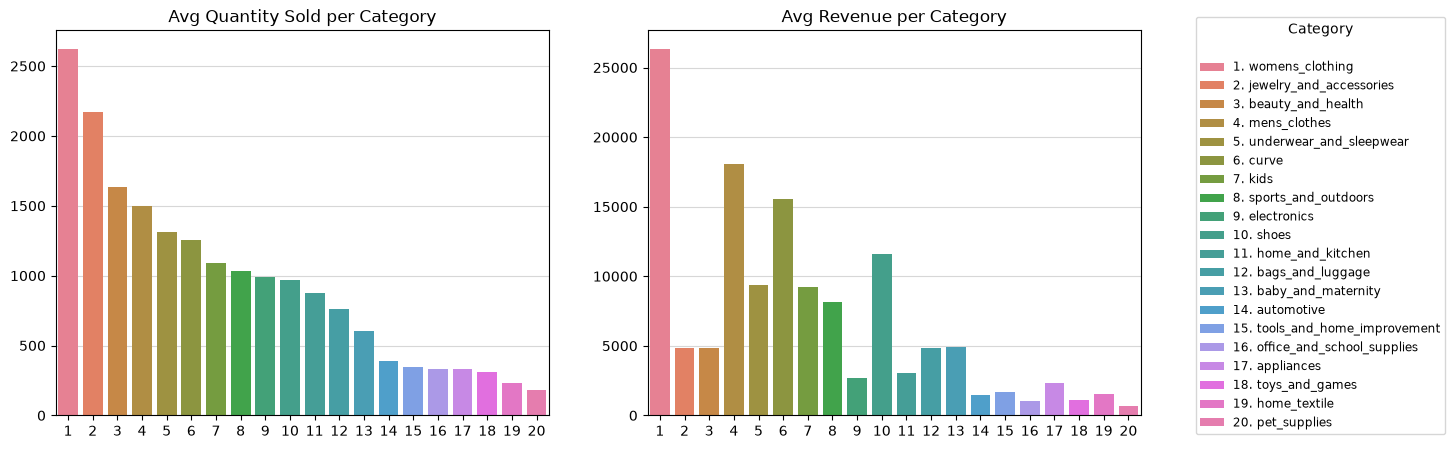

In [34]:
dup_plot_per_cat(
    kind= 'bar',
    x1= df_cat_sold.index,
    y1= df_cat_sold.values,
    x2= revenue_per_cat.index,
    y2= revenue_per_cat.values,
    title_1= 'Avg Quantity Sold per Category',
    title_2= 'Avg Revenue per Category'
)

**Full distribution (including outliers).** The averages above hide a lot of spread — box plots show how skewed quantity sold and revenue are within each category.

In [35]:
rev_qty_distro = df_an.set_index('category').loc[df_cat_sold.index].reset_index()

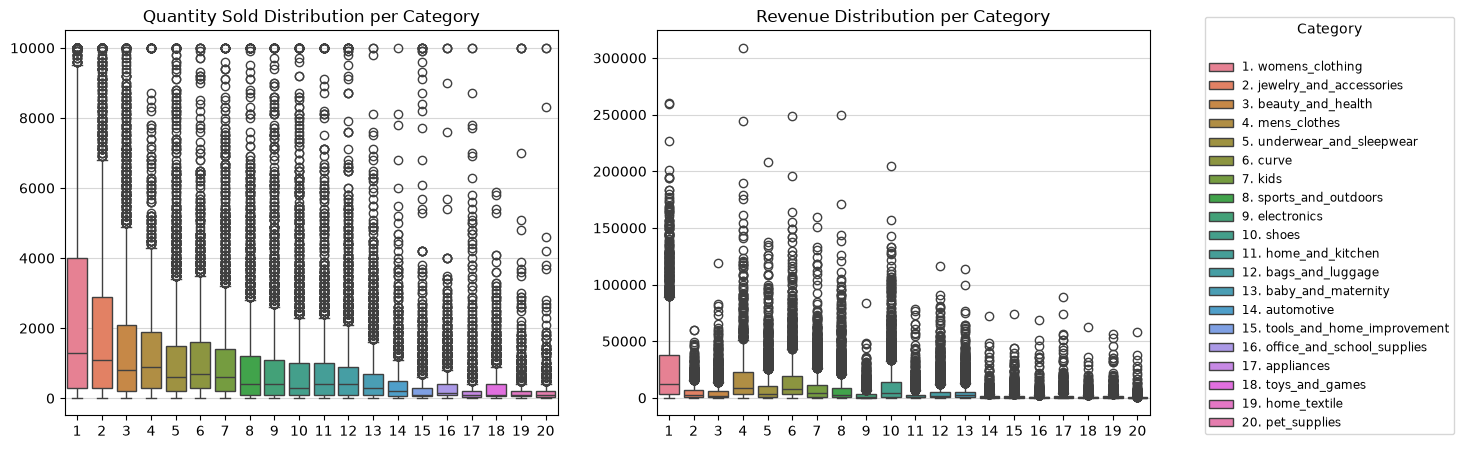

In [36]:
dup_plot_per_cat(
    kind= 'box',
    x1= rev_qty_distro.category,
    y1= rev_qty_distro.qty_sold,
    x2= rev_qty_distro.category,
    y2= rev_qty_distro.revenue,
    title_1= 'Quantity Sold Distribution per Category',
    title_2= 'Revenue Distribution per Category'
)

**Same distributions, trimmed to the 10th-90th percentile.** A handful of extreme listings dominated the previous plot; trimming outliers here makes the typical listing's performance easier to compare across categories. 

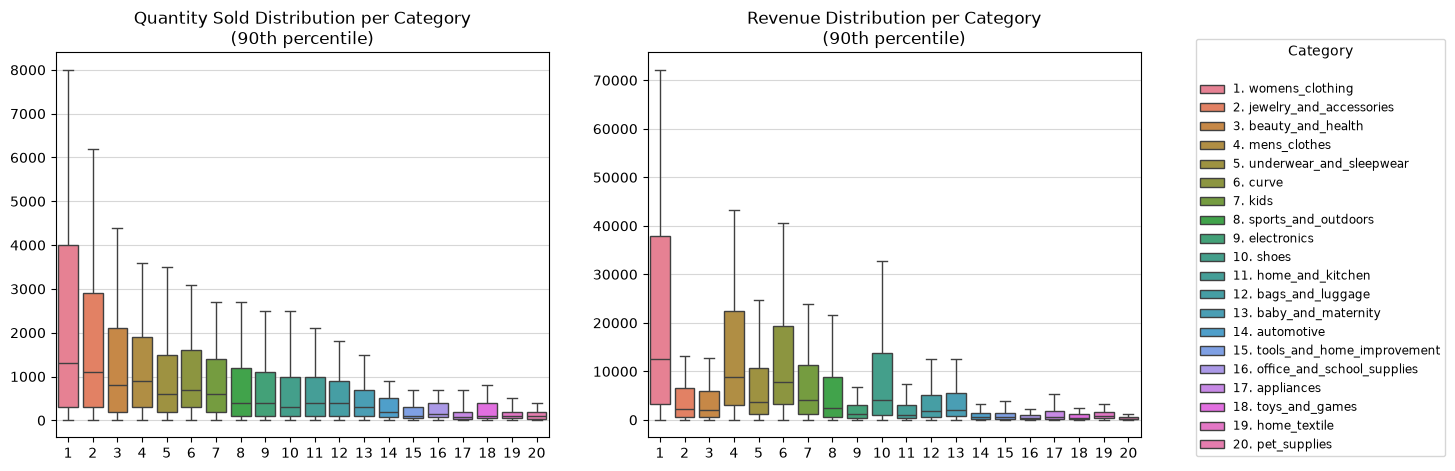

In [37]:
dup_plot_per_cat(
    kind= 'box',
    x1= rev_qty_distro.category,
    y1= rev_qty_distro.qty_sold,
    x2= rev_qty_distro.category,
    y2= rev_qty_distro.revenue,
    title_1= 'Quantity Sold Distribution per Category\n(90th percentile)',
    title_2= 'Revenue Distribution per Category\n(90th percentile)',
    whis=[0,90],
    showfliers=False
)

**Revenue generated per unit sold** — an implied, volume-weighted average selling price. This is a way to see which categories skew toward higher-ticket items.

In [38]:
revenue_sales_ratio_per_cat = df_an.groupby('category')[['revenue','qty_sold']].sum()
revenue_sales_ratio_per_cat['ratio'] = (revenue_sales_ratio_per_cat.revenue / revenue_sales_ratio_per_cat.qty_sold)
revenue_sales_ratio_per_cat = revenue_sales_ratio_per_cat.reindex(revenue_per_cat.index)


cat_q90 = df_an.groupby('category')['qty_sold'].transform(lambda s: s.quantile(0.90))
df_trimmed_by_cat = df_an[df_an['qty_sold'] <= cat_q90]

trimmed_revenue_sales_ratio = df_trimmed_by_cat.groupby('category')[['revenue','qty_sold']].sum()
trimmed_revenue_sales_ratio['ratio'] = (trimmed_revenue_sales_ratio.revenue / trimmed_revenue_sales_ratio.qty_sold)
trimmed_revenue_sales_ratio = trimmed_revenue_sales_ratio.reindex(revenue_per_cat.index)

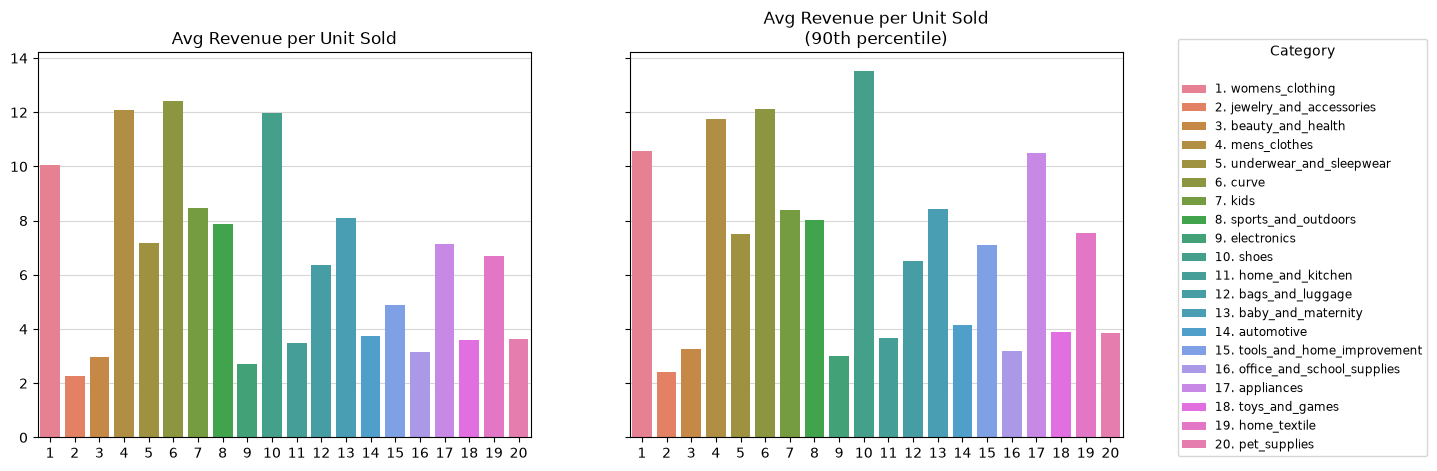

In [39]:
dup_plot_per_cat(
    kind= 'bar',
    x1= revenue_sales_ratio_per_cat.index,
    y1= revenue_sales_ratio_per_cat.ratio,
    x2= trimmed_revenue_sales_ratio.index,
    y2= trimmed_revenue_sales_ratio.ratio,
    title_1= 'Avg Revenue per Unit Sold',
    title_2= 'Avg Revenue per Unit Sold\n(90th percentile)',
    sharey=True
)

**Discount depth vs. sales volume.** A rough proxy for discount sensitivity: do categories that discount more heavily also tend to sell more? This is descriptive only — it doesn't control for other factors, so it isn't evidence of a causal relationship.

In [40]:
disc_sales_ratio = df_an.groupby('category')[['discount_pct','qty_sold']].sum()
disc_sales_ratio['ratio'] = disc_sales_ratio.discount_pct / disc_sales_ratio.qty_sold
disc_sales_ratio = disc_sales_ratio.reindex(revenue_per_cat.index)

trimmed_discount_sales_ratio = df_trimmed_by_cat.groupby('category')[['discount_pct','qty_sold']].sum()
trimmed_discount_sales_ratio['ratio'] = (trimmed_discount_sales_ratio.discount_pct / trimmed_discount_sales_ratio.qty_sold)
trimmed_discount_sales_ratio = trimmed_discount_sales_ratio.reindex(revenue_per_cat.index)

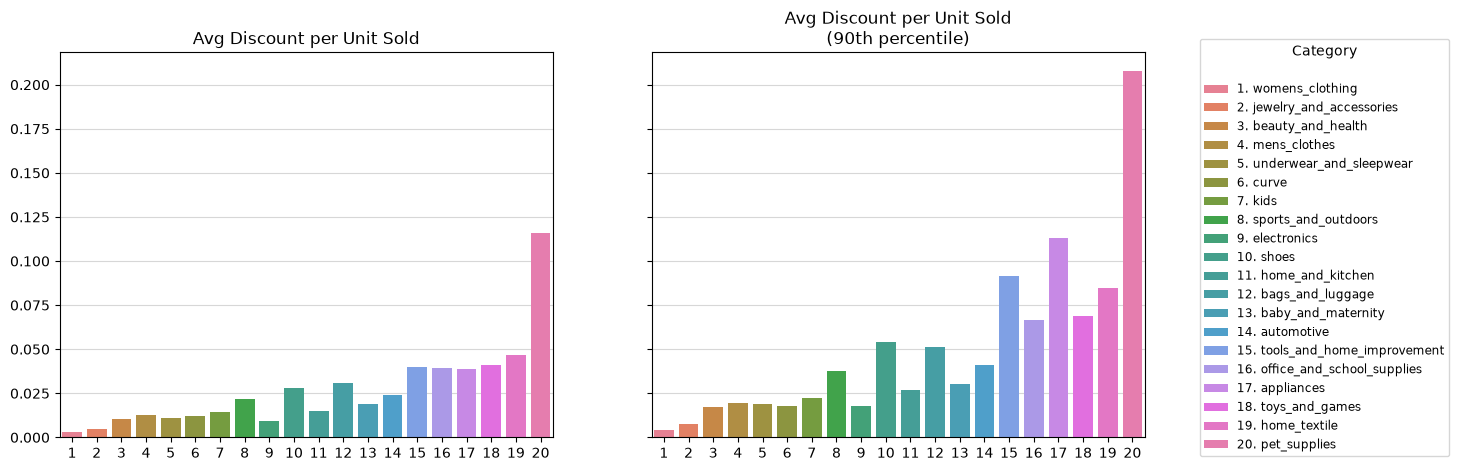

In [41]:
dup_plot_per_cat(
    kind= 'bar',
    x1= disc_sales_ratio.index,
    y1= disc_sales_ratio.ratio,
    x2= trimmed_discount_sales_ratio.index,
    y2= trimmed_discount_sales_ratio.ratio,
    title_1= 'Avg Discount per Unit Sold',
    title_2= 'Avg Discount per Unit Sold\n(90th percentile)',
    sharey=True
)

The decision of showing a 2nd plot with the 90th percentile is based on considering the typical sale cases. Two methods were available to trim the data. One taking the data as a whole, the other a category-wise approach. The pooled versions is useful for benchmarking Shein overall (e.g., against competitors); the per-category version is more useful for someone selecting which products/categories to sell or promote. I use the per-category version since it serves both use cases, and also can be useful for both small stores and Shein itself.

**Correlation matrix.** A final numeric-only check for relationships between revenue, price, discount, rank, sales and color count. Spearman's Rho will be used given that the data does not meet the statistical assumptions to be treated as parametric. 

In [42]:
df_an.drop(columns=['category', 'item_name', 'sub_cat', 'sub_cat_rank', 'NAN_sub_cat_rank', 
                    'NAN_discount_pct', 'NAN_qty_sold', 'NAN_b_friday_off','id']).corr(method='spearman')

,price_usd,discount_pct,qty_sold,color_count,b_friday_off,revenue
price_usd,1.000000,0.011247,-0.014534,0.216842,-0.032696,0.473203
discount_pct,0.011247,1.000000,-0.015622,0.131670,0.204854,-0.014619
qty_sold,-0.014534,-0.015622,1.000000,0.294830,-0.099067,0.857059
color_count,0.216842,0.131670,0.294830,1.000000,-0.019040,0.354424
b_friday_off,-0.032696,0.204854,-0.099067,-0.019040,1.000000,-0.104705
revenue,0.473203,-0.014619,0.857059,0.354424,-0.104705,1.000000


**Discount efficacy check.** A quick and cleaned correlation test will be displayed for `discount_pct` against `qty_sold` and `revenue`, to explore whether any linear correlation exists between them. `qty_sold` outliers will be removed (indirectly affecting `revenue`), and all data will be normalized using `log1p`.

In [43]:
df_corr = df_an.copy()
df_corr = df_corr[['discount_pct','qty_sold','revenue']]

q1 = df_corr.qty_sold.quantile(0.25)
q3 = df_corr.qty_sold.quantile(0.75)
iqr = q3 - q1

l_bound = q1 - 1.5 * iqr
u_bound = q3 + 1.5 * iqr

df_corr = df_corr[(df_corr.qty_sold >= l_bound) & (df_corr.qty_sold <= u_bound)]
df_corr = np.log1p(df_corr)

In [44]:
pairs = [('discount_pct', 'qty_sold'), ('discount_pct', 'revenue')]

for x, y in pairs:
    sub = df_corr[[x, y]].dropna()
    r_pearson, p_pearson = pearsonr(sub[x], sub[y])
    r_spearman, p_spearman = spearmanr(sub[x], sub[y])
    print(f'{x} vs {y}:\n   Pearson r={r_pearson:.3f} (p={p_pearson:.3g}), '
          f'Spearman ρ={r_spearman:.3f} (p={p_spearman:.3g})')

discount_pct vs qty_sold:
   Pearson r=0.042 (p=5.25e-20), Spearman ρ=0.016 (p=0.000327)
discount_pct vs revenue:
   Pearson r=0.044 (p=3.22e-22), Spearman ρ=0.006 (p=0.222)


Correlations here are all fairly weak (well under |r| = 0.3 in most cases), suggesting price, discounting, and sales volume aren't strongly linearly related at the aggregate, pooled level. Patterns visible in the category-level bar/box plots above are more likely driven by category-specific effects than by one universal price/discount/sales relationship — a natural next step would be modeling within categories rather than pooling everything together.


## 8. Key Findings & Limitations

**Findings:**
- Revenue and quantity-sold estimates vary substantially by category, with `womens_cloth` leading on average revenue and on volume, and also the category with the highest number of listings. On the contrary, `pet_supplies` is the lowest in both measures. 
- `b_friday_off` values only appear for `pet_supplies` and `sports_and_outdoors`, suggesting that promotion wasn't running (or wasn't recorded) for other categories.
- `jewelry_and_accessories` and `beauty_and_health` are 2nd and 3rd, respectively, when it comes to volume sales, but they drop to lower levels in average revenue.
- `mens_clothing`, `curve`, and `shoes` are the only categories which have a revenue higher than the volume sales.
- Considering typical sales cases, `appliances` gets better results based on average revenue.
- Despite having the lowest sales average, `pet_supplies` has the highest average discount per unit sold ratio. 
- Pooled correlations between price, discount, rank, and sales are weak — category-level dynamics matter more than any single overall trend.

**Limitations:**
- `qty_sold` is inferred from a marketing label ("X+ sold"), not verified transaction data.
- Dropped ~33.76% of the cleaned data for analysis. `appliances` significantly reduced.
- `img_url` was entirely empty across the dataset and excluded from analysis.
- Outlier handling was applied inconsistently (only in some visualizations), so headline means are sensitive to a small number of extreme listings.


## 9. Export Cleaned Dataset

Save the merged, cleaned dataframe so it can be reused (a dashboard, a modeling notebook, a BI tool) instead of living only in this notebook's memory.


In [ ]:
output_path = 'shein_cleaned.csv'
df_cl.to_csv(output_path, index=False)
print(f"Saved cleaned dataset to {output_path} ({df_cl.shape[0]} rows, {df_cl.shape[1]} columns)")